In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition/sample_submission.csv
/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition/train.zip
/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition/test.zip


In [26]:
import os

path = "/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition"

print(os.listdir(path))

['sample_submission.csv', 'train.zip', 'test.zip']


In [27]:
import zipfile

zip_path = "/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition/train.zip"

extract_path = "/kaggle/working"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done!")

Done!


In [28]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'train']


In [29]:
import os

train_path = "/kaggle/working/train"

print("Number of images:", len(os.listdir(train_path)))

print(os.listdir(train_path)[:10])

Number of images: 25001
['cat.11860.jpg', 'cat.10430.jpg', 'dog.2279.jpg', 'dog.5286.jpg', 'cat.4636.jpg', 'cat.9821.jpg', 'dog.7441.jpg', 'dog.1262.jpg', 'cat.1210.jpg', 'dog.11390.jpg']


In [30]:
import os
from PIL import Image
from torch.utils.data import Dataset

class CatsDogsDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        self.images = [
            img for img in os.listdir(image_dir)
            if img.endswith(".jpg")
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(
            self.image_dir,
            img_name
        )

        image = Image.open(
            img_path
        ).convert("RGB")

        label = 0 if img_name.startswith("cat") else 1

        if self.transform:
            image = self.transform(image)

        return image, label

In [31]:
import torchvision.models as models

weights = models.RegNet_Y_400MF_Weights.DEFAULT

transform = weights.transforms()

In [32]:
dataset = CatsDogsDataset(
    "/kaggle/working/train",
    transform=transform
)

print(len(dataset))

25000


In [33]:
from torch.utils.data import random_split

train_size = int(
    0.8 * len(dataset)
)

val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print(len(train_dataset))
print(len(val_dataset))

20000
5000


In [34]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [35]:
images, labels = next(
    iter(train_loader)
)

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


LOAD MODEL

In [36]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

weights = models.RegNet_Y_400MF_Weights.DEFAULT

model = models.regnet_y_400mf(
    weights=weights
)

Downloading: "https://download.pytorch.org/models/regnet_y_400mf-e6988f5f.pth" to /root/.cache/torch/hub/checkpoints/regnet_y_400mf-e6988f5f.pth


100%|██████████| 16.8M/16.8M [00:00<00:00, 128MB/s] 


In [37]:
print(model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 48, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=6, bias=False)
            

In [38]:
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

LOSS + OPTIMIZER

In [40]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

TRAIN

In [44]:
train_losses = []

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.0218
Epoch [2/5] Loss: 0.0118
Epoch [3/5] Loss: 0.0088
Epoch [4/5] Loss: 0.0043
Epoch [5/5] Loss: 0.0064


Validation Accuracy

In [45]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Validation Accuracy: {accuracy:.2f}%"
)

Validation Accuracy: 99.14%


Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())

        y_pred.extend(
            predicted.cpu().numpy()
        )

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[2419   23]
 [  20 2538]]


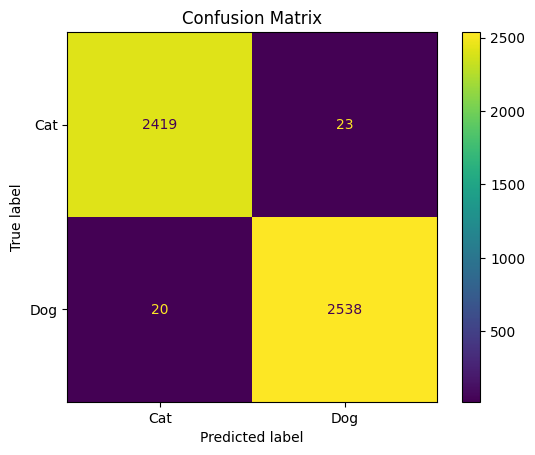

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

training loss

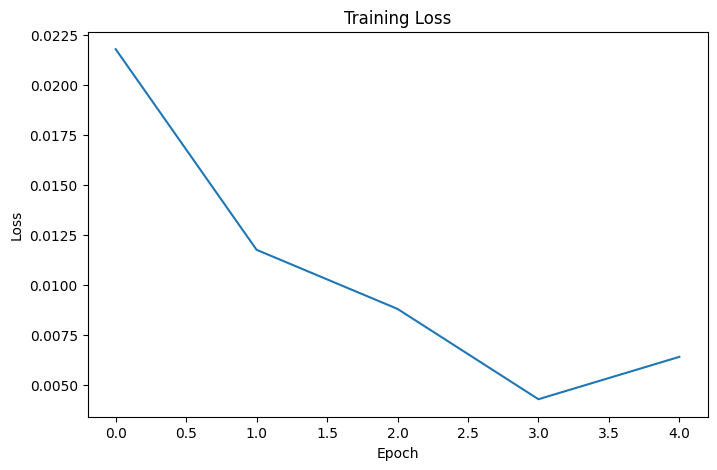

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()